In [1]:
# No terminal, uma vez: python -m pip install openpyxl pandas xlrd matplotlib seaborn
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

In [2]:
path = "Tabela_11_Domicilios_sem_presenca_de_conjuge_e_com_filhos.xlsx"

# Sexo da pessoa responsável pelo domicílio

In [3]:
#Lé todas as abas do arquivo
todas = pd.read_excel(path, skiprows=1, sheet_name=None, header=None)
print(todas.keys())

dict_keys(['BR GR UF MU', 'Tabela base do SIDRA 9882'])


In [4]:
bruto = pd.read_excel(path, sheet_name="Tabela base do SIDRA 9882", header=None)

In [5]:
bruto

,0,1,2,3
0,"Tabela 9882 - Domicílios particulares, por pre...",NaN,NaN,NaN
1,Variável - Domicílios particulares (Domicílios),NaN,NaN,NaN
2,Ano - 2022,NaN,NaN,NaN
3,"Brasil, Grande Região, Unidade da Federação e ...",Sexo da pessoa responsável pelo domicílio,NaN,NaN
4,NaN,Total,Homens,Mulheres
...,...,...,...,...
5604,Vicentinópolis (GO),352,55,297
5605,Vila Boa (GO),226,37,189
5606,Vila Propício (GO),267,49,218
5607,Brasília (DF),184921,24110,160811


In [6]:
indicador_2 = bruto.iloc[5:5608].copy()

In [7]:
indicador_2

,0,1,2,3
5,Brasil,11936510,1614739,10321771
6,Norte,909212,149246,759966
7,Nordeste,3487048,411968,3075080
8,Sudeste,5105674,700511,4405163
9,Sul,1537469,228801,1308668
...,...,...,...,...
5603,Vianópolis (GO),689,87,602
5604,Vicentinópolis (GO),352,55,297
5605,Vila Boa (GO),226,37,189
5606,Vila Propício (GO),267,49,218


In [8]:
indicador_2.columns = [
    "regiao",
    "total",
    "homens",
    "mulheres",
]


In [9]:
indicador_2 = indicador_2.reset_index(drop=True)

# horas são número, não texto
for col in indicador_2.columns[1:]:
    indicador_2[col] = pd.to_numeric(indicador_2[col], errors="coerce")

indicador_2

,regiao,total,homens,mulheres
0,Brasil,11936510,1614739,10321771
1,Norte,909212,149246,759966
2,Nordeste,3487048,411968,3075080
3,Sudeste,5105674,700511,4405163
4,Sul,1537469,228801,1308668
...,...,...,...,...
5598,Vianópolis (GO),689,87,602
5599,Vicentinópolis (GO),352,55,297
5600,Vila Boa (GO),226,37,189
5601,Vila Propício (GO),267,49,218


In [10]:
indicador_2.describe().round(2)

,total,homens,mulheres
count,5603.00,5603.00,5603.00
mean,8521.51,1152.77,7368.75
std,187979.37,25353.91,162649.37
min,23.00,3.00,16.00
25%,250.00,40.00,209.00
50%,566.00,87.00,473.00
75%,1323.50,189.00,1134.00
max,11936510.00,1614739.00,10321771.00


In [11]:
indicador_2.describe().round(2)

,total,homens,mulheres
count,5603.00,5603.00,5603.00
mean,8521.51,1152.77,7368.75
std,187979.37,25353.91,162649.37
min,23.00,3.00,16.00
25%,250.00,40.00,209.00
50%,566.00,87.00,473.00
75%,1323.50,189.00,1134.00
max,11936510.00,1614739.00,10321771.00


EXCLUIR AS CIDADES, REPAREM NO PADRÃO, ELAS TEM O () QUE INDICAM O UF

In [12]:
indicador_2 = indicador_2[~indicador_2["regiao"].str.contains(r"\(", na=False)]
indicador_2

,regiao,total,homens,mulheres
0,Brasil,11936510,1614739,10321771
1,Norte,909212,149246,759966
2,Nordeste,3487048,411968,3075080
3,Sudeste,5105674,700511,4405163
4,Sul,1537469,228801,1308668
5,Centro-Oeste,897107,124213,772894
6,Rondônia,78597,12520,66077
7,Acre,47506,7166,40340
8,Amazonas,205036,37693,167343
9,Roraima,31690,5072,26618


# Trazer a Tabela 1.1.1 (horas de trabalho doméstico) e juntar com indicador_2

In [13]:
# Mesma limpeza da Aula 2: linhas 8–40, nomes de coluna, horas como número
path_horas = r"Tabela 1.1.1.xls"
bruto_1 = pd.read_excel(path_horas, engine="xlrd", header=None)

indicador_1 = bruto_1.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [14]:
# Left join: fica tudo de indicador_2; puxa as horas da 1.1.1 quando o nome bate
# suffixes: as duas tabelas têm coluna "total" — domicílios vs horas
indicador1e2 = indicador_2.merge(
    indicador_1,
    how="left",
    left_on="regiao",
    right_on="uf_regiao",
    suffixes=("_domicilios", "_horas"),
)
indicador1e2 = indicador1e2.drop(columns=["uf_regiao"])


In [15]:
indicador1e2 = indicador1e2.rename(columns={
    "homens": "resp_domicilio_homens",
    "mulheres": "resp_domicilio_mulheres",
})
indicador1e2

,regiao,total_domicilios,resp_domicilio_homens,resp_domicilio_mulheres,total_horas,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,11936510,1614739,10321771,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,909212,149246,759966,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Nordeste,3487048,411968,3075080,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716
3,Sudeste,5105674,700511,4405163,17.104218,16.834863,17.397989,11.933522,12.180843,20.732969,21.990431
4,Sul,1537469,228801,1308668,15.527769,15.570983,15.406088,11.546629,11.159487,19.012969,19.338734
5,Centro-Oeste,897107,124213,772894,15.000763,14.826985,15.078025,10.546799,10.332059,18.220683,19.331040
6,Rondônia,78597,12520,66077,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
7,Acre,47506,7166,40340,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
8,Amazonas,205036,37693,167343,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
9,Roraima,31690,5072,26618,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244


In [16]:
# % de domicílios com responsável mulher  |  horas médias das mulheres (média das duas raças)
indicador1e2["pct_resp_mulheres"] = (
    indicador1e2["resp_domicilio_mulheres"] / indicador1e2["total_domicilios"] * 100
)
indicador1e2["horas_mulher"] = (
    indicador1e2["mulher_branca"] + indicador1e2["mulher_preta_parda"]
) / 2

indicador1e2[
    ["regiao", "pct_resp_mulheres", "horas_mulher", "resp_domicilio_mulheres", "total_domicilios"]
].sort_values("pct_resp_mulheres", ascending=False)

,regiao,pct_resp_mulheres,horas_mulher,resp_domicilio_mulheres,total_domicilios
20,Sergipe,89.542249,23.689292,139668,155980
18,Pernambuco,89.215960,23.800638,534210,598783
19,Alagoas,88.603884,24.975146,170745,192706
17,Paraíba,88.546766,23.839293,213264,240849
15,Ceará,88.469570,23.985996,494429,558869
16,Rio Grande do Norte,88.203261,23.984982,180433,204565
2,Nordeste,88.185766,23.230691,3075080,3487048
14,Piauí,87.784851,22.094752,168920,192425
21,Bahia,87.558106,22.894924,839142,958383
32,Distrito Federal,86.962000,18.522728,160811,184921


pct_resp_mulheres = em cada 100 desses domicílios, quantos têm mulher responsável.
horas_mulher = média semanal de horas das mulheres (média simples de branca e preta/parda na 1.1.1).
Como ler os dois juntos. Nordeste concentra os dois: Sergipe ~90% de responsáveis mulheres e ~24 h; Alagoas ~89% e ~25 h (mais horas). Norte tem menos lares com responsável mulher (Amazonas ~82%) e menos horas (Amapá, Acre, Roraima ~16 h). DF é o contraste: muitas responsáveis mulheres (~87%) e menos horas (~18,5 h).

In [17]:
# Neste recorte (sem cônjuge + com filhos): mulheres são maioria?
indicador_2["mais_mulheres"] = indicador_2["mulheres"] > indicador_2["homens"]

brasil = indicador_2.loc[indicador_2["regiao"] == "Brasil"].iloc[0]
print("Brasil — domicílios sem cônjuge e com filhos (Censo 2022)")
print(f"  mulheres: {int(brasil.mulheres):,}  ({brasil.mulheres/brasil.total*100:.1f}%)")
print(f"  homens:   {int(brasil.homens):,}  ({brasil.homens/brasil.total*100:.1f}%)")
print(f"  {brasil.mulheres/brasil.homens:.1f} mulheres para cada homem responsável")
print()
print("Em todas as UFs/regiões mulheres > homens?", indicador_2["mais_mulheres"].all())

indicador_2[["regiao", "homens", "mulheres", "mais_mulheres"]]

Brasil — domicílios sem cônjuge e com filhos (Censo 2022)
  mulheres: 10,321,771  (86.5%)
  homens:   1,614,739  (13.5%)
  6.4 mulheres para cada homem responsável

Em todas as UFs/regiões mulheres > homens? True


,regiao,homens,mulheres,mais_mulheres
0,Brasil,1614739,10321771,True
1,Norte,149246,759966,True
2,Nordeste,411968,3075080,True
3,Sudeste,700511,4405163,True
4,Sul,228801,1308668,True
5,Centro-Oeste,124213,772894,True
6,Rondônia,12520,66077,True
7,Acre,7166,40340,True
8,Amazonas,37693,167343,True
9,Roraima,5072,26618,True


## Gráficos com matplotlib e seaborn

Visualizamos o recorte **domicílios sem cônjuge e com filhos** e as **horas de afazeres** da Tabela 1.1.1.

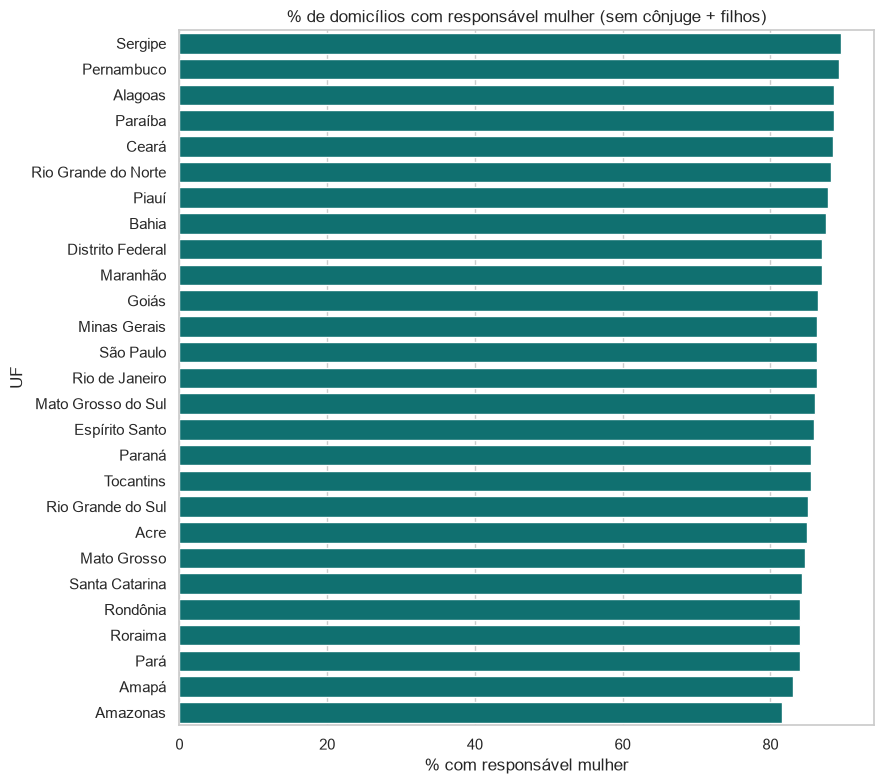

In [18]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
ufs = indicador1e2[~indicador1e2["regiao"].isin(["Brasil"] + regioes)].copy()

# Barras: % de domicílios com responsável mulher
fig, ax = plt.subplots(figsize=(9, 8))
ordem = ufs.sort_values("pct_resp_mulheres", ascending=False)
sns.barplot(data=ordem, y="regiao", x="pct_resp_mulheres", ax=ax, color="teal")
ax.set_title("% de domicílios com responsável mulher (sem cônjuge + filhos)")
ax.set_xlabel("% com responsável mulher")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()

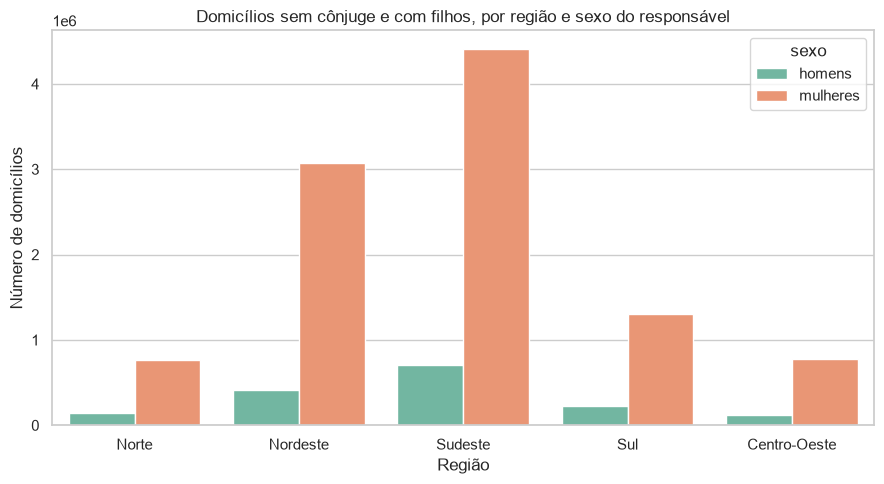

In [19]:
# Barras agrupadas: responsáveis homens x mulheres por grande região
reg = indicador_2[indicador_2["regiao"].isin(regioes)].copy()
reg_long = reg.melt(
    id_vars="regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="domicilios",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="regiao", y="domicilios", hue="sexo", ax=ax)
ax.set_title("Domicílios sem cônjuge e com filhos, por região e sexo do responsável")
ax.set_xlabel("Região")
ax.set_ylabel("Número de domicílios")
plt.tight_layout()
plt.show()

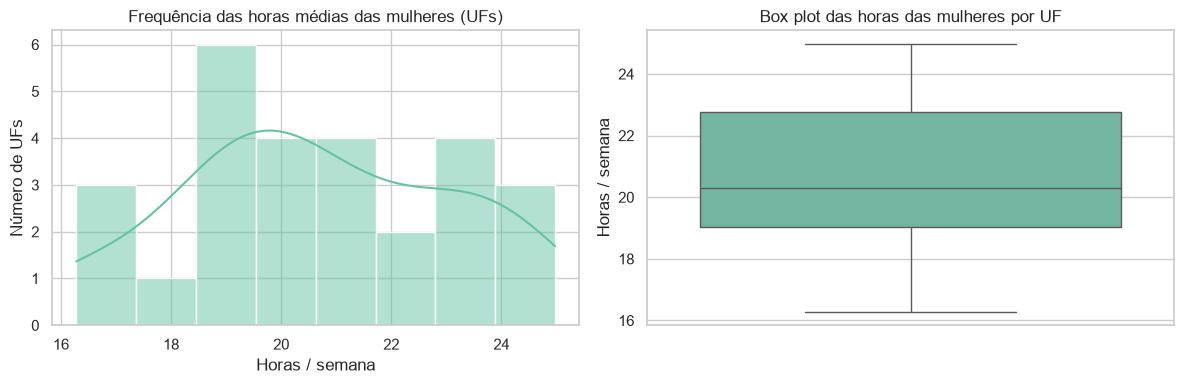

In [20]:
# Histograma (frequência) e box plot das horas das mulheres
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(ufs["horas_mulher"], bins=8, kde=True, ax=axes[0])
axes[0].set_title("Frequência das horas médias das mulheres (UFs)")
axes[0].set_xlabel("Horas / semana")
axes[0].set_ylabel("Número de UFs")

sns.boxplot(y=ufs["horas_mulher"], ax=axes[1])
axes[1].set_title("Box plot das horas das mulheres por UF")
axes[1].set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()

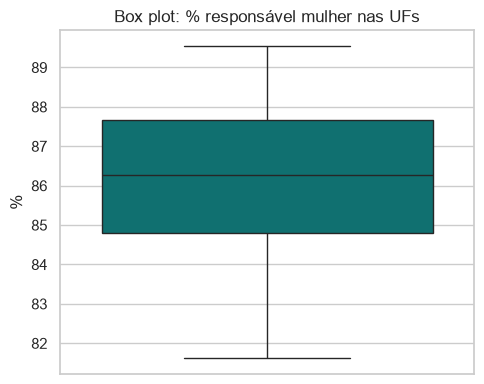

In [21]:
# Box plot: % de responsáveis mulheres por UF
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(y=ufs["pct_resp_mulheres"], ax=ax, color="teal")
ax.set_title("Box plot: % responsável mulher nas UFs")
ax.set_ylabel("%")
plt.tight_layout()
plt.show()

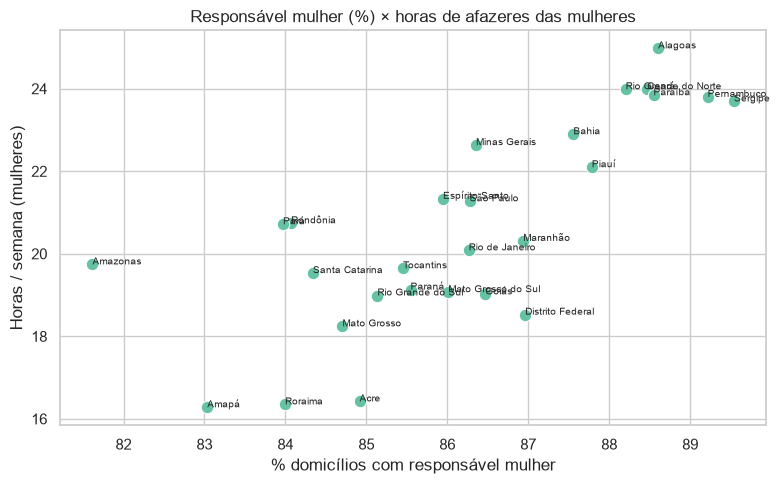

In [22]:
# Dispersão: será que mais responsáveis mulheres anda junto com mais horas em casa?
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=ufs, x="pct_resp_mulheres", y="horas_mulher", ax=ax, s=80)
for _, row in ufs.iterrows():
    ax.annotate(row["regiao"], (row["pct_resp_mulheres"], row["horas_mulher"]), fontsize=7)
ax.set_title("Responsável mulher (%) × horas de afazeres das mulheres")
ax.set_xlabel("% domicílios com responsável mulher")
ax.set_ylabel("Horas / semana (mulheres)")
plt.tight_layout()
plt.show()

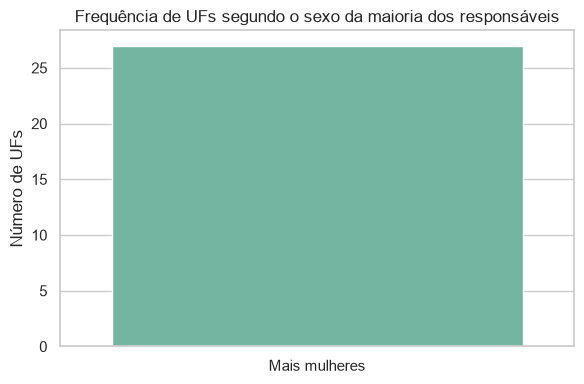

In [24]:
# Frequência: neste recorte, mulheres são maioria entre os responsáveis?

ufs["maioria"] = "Mais mulheres"
ufs.loc[ufs["resp_domicilio_mulheres"] <= ufs["resp_domicilio_homens"], "maioria"] = "Mais homens"

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=ufs, x="maioria", ax=ax)
ax.set_title("Frequência de UFs segundo o sexo da maioria dos responsáveis")
ax.set_xlabel("")
ax.set_ylabel("Número de UFs")
plt.tight_layout()
plt.show()